In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("../data/processed/dk2_merged_price_weather_energy.csv")

df["HourUTC"] = pd.to_datetime(df["HourUTC"])
df["HourDK"] = pd.to_datetime(df["HourDK"])

df = df.sort_values("HourUTC").reset_index(drop=True)

df.head()

,HourUTC,HourDK,PriceArea,SpotPriceEUR,hour,day_of_week,month,year,is_weekend,price_lag_24h,...,offshore_wind_mwh,onshore_wind_mwh,solar_mwh,total_wind_mwh,renewable_generation_mwh,net_load_mwh,ExchangeSE_MWh,ExchangeGE_MWh,ExchangeGreatBelt_MWh,PowerToHeatMWh
0,2024-08-17 06:00:00,2024-08-17 08:00:00,DK2,103.430000,8,5,8,2024,1,124.830002,...,139.575607,12.631012,290.954754,152.206619,443.161373,913.084285,1004.938750,-542.164000,181.2,32.783193
1,2024-08-17 07:00:00,2024-08-17 09:00:00,DK2,84.000000,9,5,8,2024,1,100.949997,...,111.449682,14.223518,464.444211,125.673200,590.117411,897.563125,1164.431492,-839.658984,202.5,24.287895
2,2024-08-17 08:00:00,2024-08-17 10:00:00,DK2,69.489998,10,5,8,2024,1,76.150002,...,86.846481,11.792317,592.522881,98.638798,691.161679,871.185718,1220.923492,-943.107016,244.5,15.592138
3,2024-08-17 09:00:00,2024-08-17 11:00:00,DK2,54.160000,11,5,8,2024,1,59.830002,...,56.012000,14.692761,641.920324,70.704761,712.625085,884.160102,1320.748250,-959.805000,171.9,14.801758
4,2024-08-17 10:00:00,2024-08-17 12:00:00,DK2,46.830002,12,5,8,2024,1,50.680000,...,35.773500,14.832262,675.559553,50.605762,726.165315,868.566350,1008.507250,-865.089992,340.9,12.442353


In [3]:
df["target_24h_ahead"] = df["SpotPriceEUR"].shift(-24)

In [4]:
df_24h = df.dropna(subset=["target_24h_ahead"]).reset_index(drop=True)

print("Rows:", len(df_24h))
print("Date range:", df_24h["HourUTC"].min(), "→", df_24h["HourUTC"].max())

Rows: 9800
Date range: 2024-08-17 06:00:00 → 2025-09-29 13:00:00


In [5]:
df_24h["pred_baseline_current_price"] = df_24h["SpotPriceEUR"]

In [6]:
df_24h["pred_baseline_rolling_24h"] = df_24h["price_rolling_mean_24h"]
df_24h["pred_baseline_rolling_168h"] = df_24h["price_rolling_mean_168h"]

In [7]:
target_col = "target_24h_ahead"

exclude_cols = [
    "HourUTC",
    "HourDK",
    "PriceArea",
    "target_next_hour",
    "target_24h_ahead",
    "pred_baseline_current_price",
    "pred_baseline_rolling_24h",
    "pred_baseline_rolling_168h",
]

feature_cols = [col for col in df_24h.columns if col not in exclude_cols]

X = df_24h[feature_cols].select_dtypes(include=["number"])
y = df_24h[target_col]

feature_cols = X.columns.tolist()

feature_cols

['SpotPriceEUR',
 'hour',
 'day_of_week',
 'month',
 'year',
 'is_weekend',
 'price_lag_24h',
 'price_lag_48h',
 'price_lag_168h',
 'price_rolling_mean_24h',
 'price_rolling_std_24h',
 'price_rolling_mean_168h',
 'price_rolling_std_168h',
 'temperature_2m',
 'wind_speed_10m',
 'wind_speed_100m',
 'cloud_cover',
 'shortwave_radiation',
 'GrossConsumptionMWh',
 'CentralPowerMWh',
 'LocalPowerMWh',
 'CommercialPowerMWh',
 'offshore_wind_mwh',
 'onshore_wind_mwh',
 'solar_mwh',
 'total_wind_mwh',
 'renewable_generation_mwh',
 'net_load_mwh',
 'ExchangeSE_MWh',
 'ExchangeGE_MWh',
 'ExchangeGreatBelt_MWh',
 'PowerToHeatMWh']

In [8]:
train_size = int(len(df_24h) * 0.7)
train = df_24h.iloc[:train_size].copy()
test = df_24h.iloc[train_size:].copy()

X_train = train[feature_cols]
y_train = train[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train range:", train["HourUTC"].min(), "→", train["HourUTC"].max())
print("Test range:", test["HourUTC"].min(), "→", test["HourUTC"].max())

Train: (6860, 32)
Test: (2940, 32)
Train range: 2024-08-17 06:00:00 → 2025-05-30 01:00:00
Test range: 2025-05-30 02:00:00 → 2025-09-29 13:00:00


In [9]:
xgb_24h = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_24h.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [10]:
test["pred_xgboost_24h"] = xgb_24h.predict(X_test)

In [11]:
def evaluate_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        "model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
    }

In [12]:
results = []

results.append(evaluate_forecast(
    test["target_24h_ahead"],
    test["pred_baseline_current_price"],
    "Current price baseline 24h"
))

results.append(evaluate_forecast(
    test["target_24h_ahead"],
    test["pred_baseline_rolling_24h"],
    "Rolling mean 24h baseline"
))

results.append(evaluate_forecast(
    test["target_24h_ahead"],
    test["pred_baseline_rolling_168h"],
    "Rolling mean 168h baseline"
))

results.append(evaluate_forecast(
    test["target_24h_ahead"],
    test["pred_xgboost_24h"],
    "XGBoost 24h"
))

results_24h = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
results_24h

,model,MAE,RMSE
0,XGBoost 24h,25.38,34.53
1,Current price baseline 24h,28.30,42.29
2,Rolling mean 168h baseline,37.69,49.88
3,Rolling mean 24h baseline,40.72,53.81


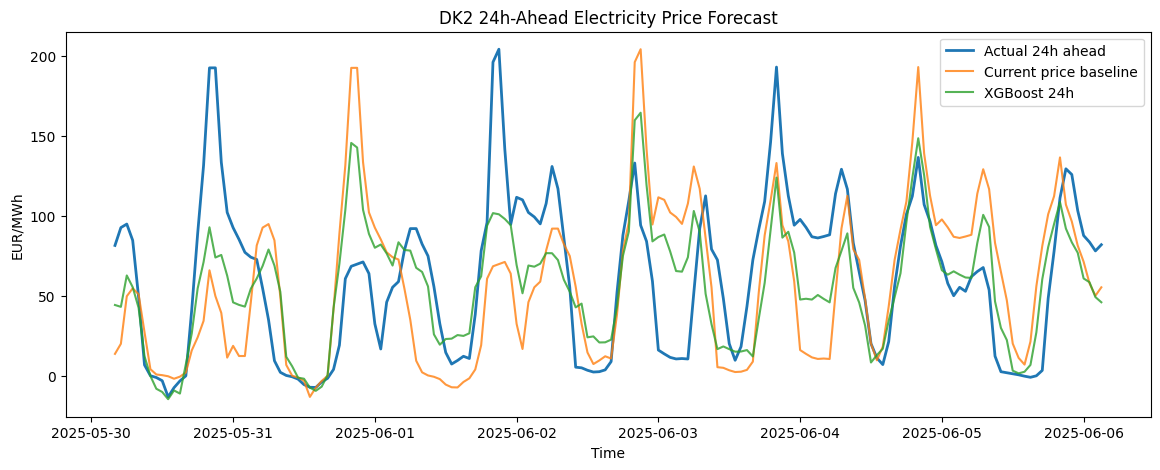

In [13]:
sample = test.head(168)

plt.figure(figsize=(14, 5))

plt.plot(
    sample["HourDK"],
    sample["target_24h_ahead"],
    label="Actual 24h ahead",
    linewidth=2
)

plt.plot(
    sample["HourDK"],
    sample["pred_baseline_current_price"],
    label="Current price baseline",
    alpha=0.8
)

plt.plot(
    sample["HourDK"],
    sample["pred_xgboost_24h"],
    label="XGBoost 24h",
    alpha=0.8
)

plt.title("DK2 24h-Ahead Electricity Price Forecast")
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.legend()
plt.show()

In [14]:
importance_24h = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_24h.feature_importances_
}).sort_values("importance", ascending=False)

importance_24h.head(20)

,feature,importance
0,SpotPriceEUR,0.201506
17,shortwave_radiation,0.097247
27,net_load_mwh,0.092547
21,CommercialPowerMWh,0.060198
24,solar_mwh,0.054846
8,price_lag_168h,0.046407
30,ExchangeGreatBelt_MWh,0.028728
3,month,0.028333
22,offshore_wind_mwh,0.025650
2,day_of_week,0.024887


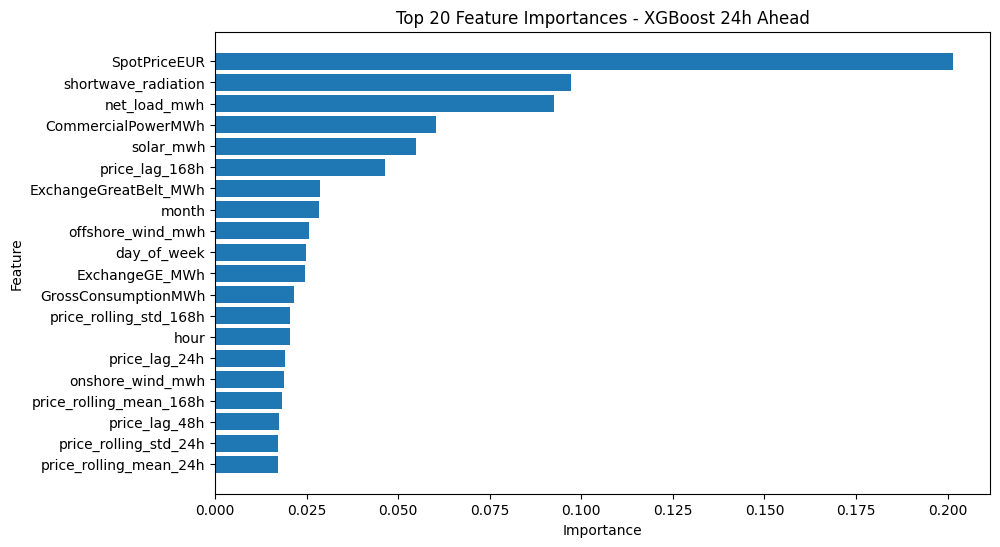

In [15]:
top_importance = importance_24h.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_importance["feature"][::-1], top_importance["importance"][::-1])
plt.title("Top 20 Feature Importances - XGBoost 24h Ahead")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [16]:
from pathlib import Path

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

results_24h.to_csv("../reports/model_comparison_24h_DK2.csv", index=False)
importance_24h.to_csv("../reports/xgboost_24h_feature_importance_DK2.csv", index=False)

## Conclusion

This notebook extends the forecasting task from next-hour prediction to 24-hour-ahead prediction.

The XGBoost model achieved a MAE of 25.58 EUR/MWh and RMSE of 34.89 EUR/MWh. It outperformed the current-price baseline, which achieved a MAE of 28.30 EUR/MWh and RMSE of 42.29 EUR/MWh.

This corresponds to a MAE improvement of approximately 9.61% over the strongest naive baseline. The result suggests that the model is learning useful 24-hour-ahead patterns from price history, calendar features, weather variables, production, consumption, renewable generation, net load, and exchange flows.

Feature importance shows that the current price, net load, commercial power, solar generation, shortwave radiation, weekly lag, consumption, and exchange variables are relevant predictors for the 24-hour-ahead forecast.

Overall, this is a solid baseline for 24-hour-ahead electricity price forecasting and a good foundation before moving to LSTM-based sequence models.

In [17]:
baseline_mae = results_24h.loc[
    results_24h["model"] == "Current price baseline 24h", "MAE"
].values[0]

xgb_mae = results_24h.loc[
    results_24h["model"] == "XGBoost 24h", "MAE"
].values[0]

mae_improvement = (baseline_mae - xgb_mae) / baseline_mae * 100

print(f"MAE improvement vs current price baseline: {mae_improvement:.2f}%")

MAE improvement vs current price baseline: 10.32%
